Capítulo 1

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


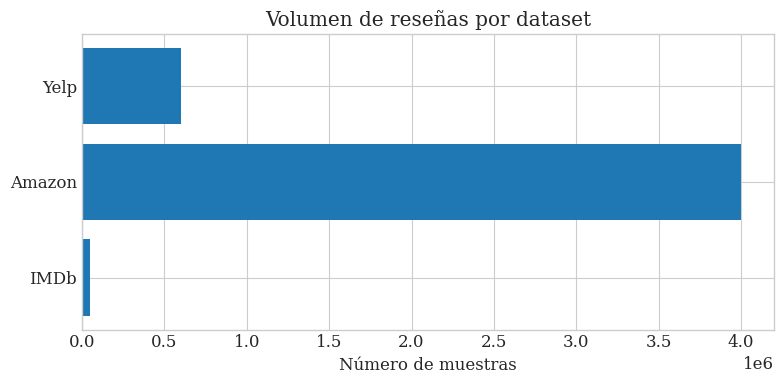

In [ ]:
# 1.1
# Montar el disco
from google.colab import drive
drive.mount('/content/drive')
base_path = "/content/drive/MyDrive/TFG_Data/RAW/"


def count_rows(filepath):
    with open(filepath, encoding="utf-8") as f:
        return sum(1 for _ in f) - 1  # se resta la cabecera

files = {
    "IMDb": ["IMDB.csv"],
    "Amazon": ["Amazon_train.csv", "Amazon_test.csv"],
    "Yelp": ["Yelp_train.csv", "Yelp_test.csv"]
}

dataset_counts = {}

for dataset, file_list in files.items():
    total = 0
    for file in file_list:
        total += count_rows(base_path + file)
    dataset_counts[dataset] = total

dataset_counts

import matplotlib.pyplot as plt

datasets = list(dataset_counts.keys())
samples = list(dataset_counts.values())

plt.figure(figsize=(8, 4))
plt.barh(datasets, samples)
plt.xlabel("Número de muestras")
plt.title("Volumen de reseñas por dataset")
plt.tight_layout()
plt.show()

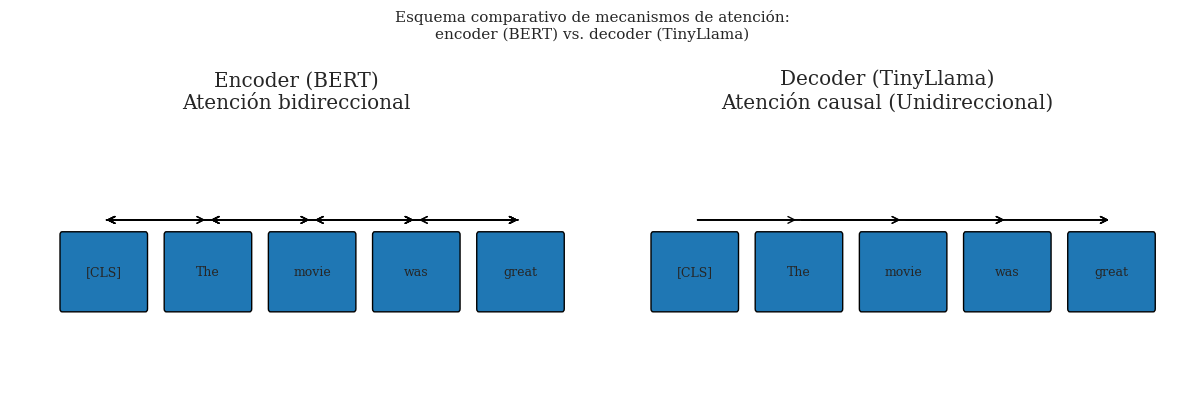

In [ ]:
# 1.2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
def draw_tokens(ax, tokens, y, box_width=0.8):
    for i, token in enumerate(tokens):
        rect = patches.FancyBboxPatch(
            (i, y),
            box_width,
            0.5,
            boxstyle="round,pad=0.02"
        )
        ax.add_patch(rect)
        ax.text(i + box_width / 2, y + 0.25, token,
                ha='center', va='center', fontsize=9)
def draw_attention(ax, i, j, y, direction="both"):
    if direction in ["both", "forward"]:
        ax.annotate("", xy=(j, y), xytext=(i, y),
                    arrowprops=dict(arrowstyle="->", lw=1))
    if direction in ["both", "backward"]:
        ax.annotate("", xy=(i, y), xytext=(j, y),
                    arrowprops=dict(arrowstyle="->", lw=1))
tokens = ["[CLS]", "The", "movie", "was", "great"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Encoder (BERT)
ax = axes[0]
draw_tokens(ax, tokens, y=1)

for i in range(len(tokens)):
    for j in range(len(tokens)):
        if i != j:
            draw_attention(ax, i + 0.4, j + 0.4, y=1.6, direction="both")

ax.set_title("Encoder (BERT)\nAtención bidireccional")
ax.set_xlim(-0.5, len(tokens))
ax.set_ylim(0.5, 2.3)
ax.axis("off")

# Decoder (TinyLlama)
ax = axes[1]
draw_tokens(ax, tokens, y=1)

for i in range(len(tokens)):
    for j in range(i):
        draw_attention(ax, j + 0.4, i + 0.4, y=1.6, direction="forward")

ax.set_title("Decoder (TinyLlama)\nAtención causal (Unidireccional)")
ax.set_xlim(-0.5, len(tokens))
ax.set_ylim(0.5, 2.3)
ax.axis("off")

plt.suptitle(
    "Esquema comparativo de mecanismos de atención:\n"
    "encoder (BERT) vs. decoder (TinyLlama)",
    fontsize=11
)

plt.tight_layout()
plt.show()



Capítulo 2

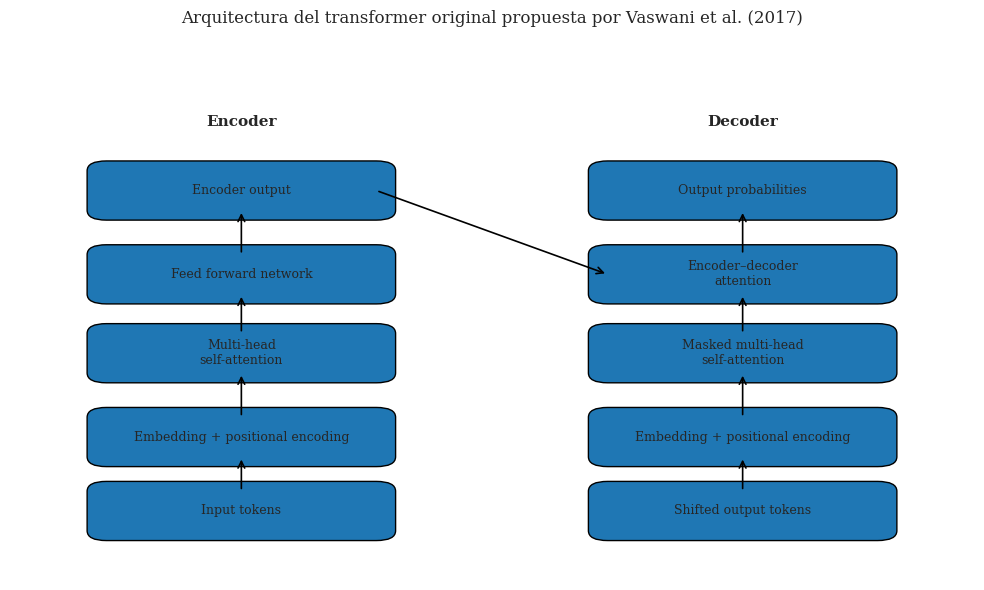

In [ ]:
#2.1
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_box(ax, xy, width, height, text, fontsize=9):
    rect = patches.FancyBboxPatch(
        xy, width, height,
        boxstyle="round,pad=0.02"
    )
    ax.add_patch(rect)
    ax.text(
        xy[0] + width / 2,
        xy[1] + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize
    )

def draw_arrow(ax, start, end):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", lw=1.2)
    )

fig, ax = plt.subplots(figsize=(10, 6))

# Encoder (izquierda)
enc_x = 0.1
enc_w = 0.28

# Decoder (derecha)
dec_x = 0.62
dec_w = 0.28

# Alturas
y_input = 0.1
y_embed = 0.25
y_attn = 0.42
y_ffn  = 0.58
y_out  = 0.75

box_h = 0.08

# Encoder
draw_box(ax, (enc_x, y_input), enc_w, box_h, "Input tokens")
draw_box(ax, (enc_x, y_embed), enc_w, box_h, "Embedding + positional encoding")
draw_box(ax, (enc_x, y_attn), enc_w, box_h, "Multi-head\nself-attention")
draw_box(ax, (enc_x, y_ffn), enc_w, box_h, "Feed forward network")
draw_box(ax, (enc_x, y_out), enc_w, box_h, "Encoder output")

draw_arrow(ax, (enc_x + enc_w/2, y_input + box_h), (enc_x + enc_w/2, y_embed))
draw_arrow(ax, (enc_x + enc_w/2, y_embed + box_h), (enc_x + enc_w/2, y_attn))
draw_arrow(ax, (enc_x + enc_w/2, y_attn + box_h), (enc_x + enc_w/2, y_ffn))
draw_arrow(ax, (enc_x + enc_w/2, y_ffn + box_h), (enc_x + enc_w/2, y_out))

# Decoder
draw_box(ax, (dec_x, y_input), dec_w, box_h, "Shifted output tokens")
draw_box(ax, (dec_x, y_embed), dec_w, box_h, "Embedding + positional encoding")
draw_box(ax, (dec_x, y_attn), dec_w, box_h, "Masked multi-head\nself-attention")
draw_box(ax, (dec_x, y_ffn), dec_w, box_h, "Encoder–decoder\nattention")
draw_box(ax, (dec_x, y_out), dec_w, box_h, "Output probabilities")


draw_arrow(ax, (dec_x + dec_w/2, y_input + box_h), (dec_x + dec_w/2, y_embed))
draw_arrow(ax, (dec_x + dec_w/2, y_embed + box_h), (dec_x + dec_w/2, y_attn))
draw_arrow(ax, (dec_x + dec_w/2, y_attn + box_h), (dec_x + dec_w/2, y_ffn))
draw_arrow(ax, (dec_x + dec_w/2, y_ffn + box_h), (dec_x + dec_w/2, y_out))

draw_arrow(
    ax,
    (enc_x + enc_w, y_out + box_h/2),
    (dec_x, y_ffn + box_h/2)
)

ax.text(enc_x + enc_w/2, 0.92, "Encoder", ha="center", fontsize=11, fontweight="bold")
ax.text(dec_x + dec_w/2, 0.92, "Decoder", ha="center", fontsize=11, fontweight="bold")

plt.suptitle(
    "Arquitectura del transformer original propuesta por Vaswani et al. (2017)",
    fontsize=12
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

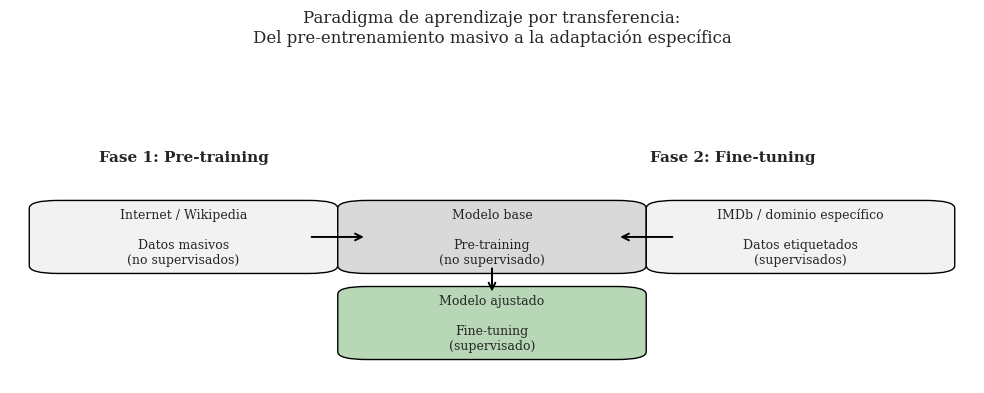

In [ ]:
#2.2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_box(ax, xy, width, height, text, fontsize=9, facecolor="#EEEEEE"):
    rect = patches.FancyBboxPatch(
        xy, width, height,
        boxstyle="round,pad=0.03",
        facecolor=facecolor,
        edgecolor="black"
    )
    ax.add_patch(rect)
    ax.text(
        xy[0] + width / 2,
        xy[1] + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        wrap=True
    )

def draw_arrow(ax, start, end):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", lw=1.4)
    )

fig, ax = plt.subplots(figsize=(10, 4))

# Fase 1 (Pre-training)
left_x = 0.05
center_x = 0.37

# Fase 2 (Fine-tuning)
right_x = 0.69

box_w = 0.26
box_h = 0.22
y_box = 0.45

# Fase 1: Pre-training
draw_box(ax, (left_x, y_box), box_w, box_h, "Internet / Wikipedia\n\nDatos masivos\n(no supervisados)", fontsize=9, facecolor="#F2F2F2")

draw_box(ax, (center_x, y_box), box_w, box_h, "Modelo base\n\nPre-training\n(no supervisado)", fontsize=9, facecolor="#D9D9D9")

draw_arrow(ax, (left_x + box_w, y_box + box_h / 2), (center_x, y_box + box_h / 2))

# Fase 2: Fine-tuning
draw_box(ax, (right_x, y_box), box_w, box_h, "IMDb / dominio específico\n\nDatos etiquetados\n(supervisados)", fontsize=9, facecolor="#F2F2F2")

draw_box(ax, (center_x, 0.12), box_w, box_h, "Modelo ajustado\n\nFine-tuning\n(supervisado)", fontsize=9, facecolor="#B7D7B7")

draw_arrow(ax, (center_x + box_w / 2, y_box), (center_x + box_w / 2, 0.12 + box_h))

draw_arrow(ax, (right_x, y_box + box_h / 2), (center_x + box_w, y_box + box_h / 2))

ax.text(0.18, 0.85, "Fase 1: Pre-training", ha="center", fontsize=11, fontweight="bold")
ax.text(0.75, 0.85, "Fase 2: Fine-tuning", ha="center", fontsize=11, fontweight="bold")

plt.suptitle(
    "Paradigma de aprendizaje por transferencia:\n"
    "Del pre-entrenamiento masivo a la adaptación específica",
    fontsize=12
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()



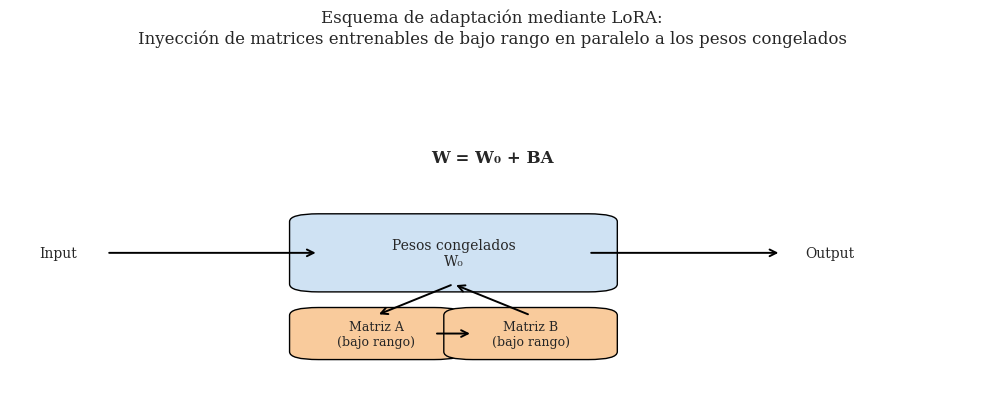

In [ ]:
# 2.3.

import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_box(ax, xy, width, height, text, fontsize=9, facecolor="#E6E6E6"):
    rect = patches.FancyBboxPatch(
        xy, width, height,
        boxstyle="round,pad=0.03",
        facecolor=facecolor,
        edgecolor="black"
    )
    ax.add_patch(rect)
    ax.text(
        xy[0] + width / 2,
        xy[1] + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        wrap=True
    )

def draw_arrow(ax, start, end):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", lw=1.4)
    )

fig, ax = plt.subplots(figsize=(10, 4))

# Entrada y salida
x_input = 0.05
x_output = 0.85
y_center = 0.5

# Bloque principal (W0)
w0_x = 0.32
w0_y = 0.38
w0_w = 0.28
w0_h = 0.24

# Bloques LoRA
a_x = 0.32
a_y = 0.12
a_w = 0.12
a_h = 0.14

b_x = 0.48
b_y = 0.12
b_w = 0.12
b_h = 0.14

# Entrada
ax.text(x_input, y_center, "Input", fontsize=10, ha="center", va="center")
draw_arrow(ax, (x_input + 0.05, y_center), (w0_x, y_center))

# Pesos congelados
draw_box(ax, (w0_x, w0_y), w0_w, w0_h, "Pesos congelados\nW₀", fontsize=10, facecolor="#CFE2F3")

# LoRA
draw_box(ax, (a_x, a_y), a_w, a_h, "Matriz A\n(bajo rango)", fontsize=9, facecolor="#F9CB9C")

draw_box(ax, (b_x, b_y), b_w, b_h, "Matriz B\n(bajo rango)", fontsize=9, facecolor="#F9CB9C")

# Flechas LoRA
draw_arrow(ax, (w0_x + w0_w / 2, w0_y), (a_x + a_w / 2, a_y + a_h))
draw_arrow(ax, (a_x + a_w, a_y + a_h / 2), (b_x, b_y + a_h / 2))
draw_arrow(ax, (b_x + b_w / 2, b_y + b_h), (w0_x + w0_w / 2, w0_y))

# Salida
draw_arrow(ax, (w0_x + w0_w, y_center), (x_output - 0.05, y_center))
ax.text(x_output, y_center, "Output", fontsize=10, ha="center", va="center")

# Ecuación visual
ax.text(0.5, 0.85, "W = W₀ + BA", fontsize=12, ha="center", fontweight="bold")

# Título
plt.suptitle(
    "Esquema de adaptación mediante LoRA:\n"
    "Inyección de matrices entrenables de bajo rango en paralelo a los pesos congelados",
    fontsize=12
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

Capítulo 3

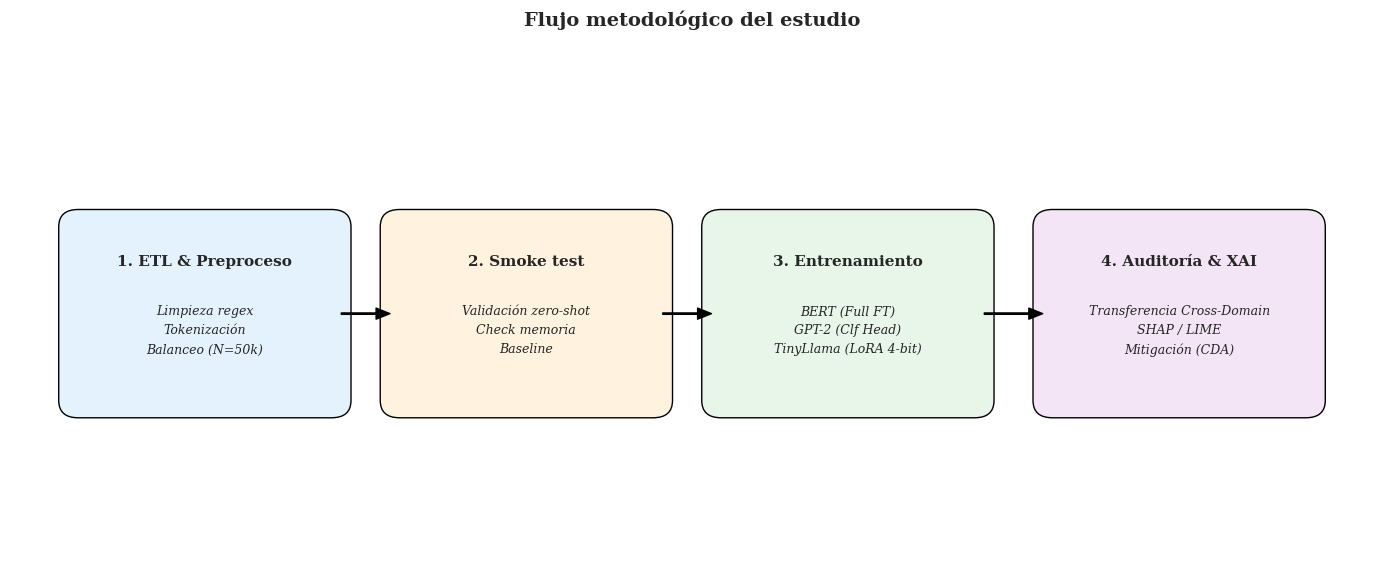

In [ ]:
# 3.1.
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_pipeline():
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 6)
    ax.axis('off')

    # Estilos
    box_props = dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', edgecolor='#333333', linewidth=1.5)
    arrow_props = dict(facecolor='black', width=1, headwidth=8, headlength=10)
    font_title = {'fontname': 'serif', 'weight': 'bold', 'size': 11}
    font_desc = {'fontname': 'serif', 'style': 'italic', 'size': 9}

    # Fases
    phases = [
        {"title": "1. ETL & Preproceso", "desc": "Limpieza regex\nTokenización\nBalanceo (N=50k)", "x": 2, "y": 3, "color": "#e3f2fd"},
        {"title": "2. Smoke test", "desc": "Validación zero-shot\nCheck memoria\nBaseline", "x": 5.3, "y": 3, "color": "#fff3e0"},
        {"title": "3. Entrenamiento", "desc": "BERT (Full FT)\nGPT-2 (Clf Head)\nTinyLlama (LoRA 4-bit)", "x": 8.6, "y": 3, "color": "#e8f5e9"},
        {"title": "4. Auditoría & XAI", "desc": "Transferencia Cross-Domain\nSHAP / LIME\nMitigación (CDA)", "x": 12, "y": 3, "color": "#f3e5f5"}
    ]

    for i, p in enumerate(phases):
        # Caja Principal
        ax.add_patch(patches.FancyBboxPatch((p["x"]-1.3, p["y"]-1), 2.6, 2, boxstyle='round,pad=0.2',
                                            facecolor=p["color"], edgecolor='black', linewidth=1))
        # Texto
        ax.text(p["x"], p["y"]+0.6, p["title"], ha='center', va='center', **font_title)
        ax.text(p["x"], p["y"]-0.2, p["desc"], ha='center', va='center', **font_desc, linespacing=1.6)

        # Flechas
        if i < len(phases) - 1:
            ax.annotate('', xy=(phases[i+1]["x"]-1.4, 3), xytext=(p["x"]+1.4, 3), arrowprops=arrow_props)

    # Título
    plt.title("Flujo metodológico del estudio", fontsize=14, fontname='serif', weight='bold', pad=20)
    plt.tight_layout()
    plt.show()

draw_pipeline()

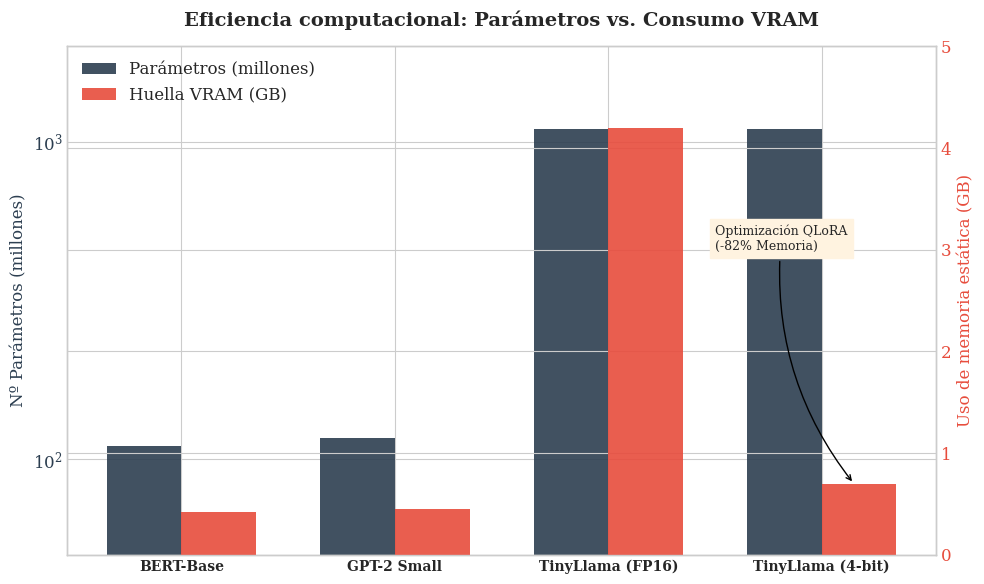

In [ ]:
# 3.2.
import matplotlib.pyplot as plt
import numpy as np

def draw_resource_comparison():
    # Datos de la memoria (capítulos 3 y 10)
    models = ['BERT-Base', 'GPT-2 Small', 'TinyLlama (FP16)', 'TinyLlama (4-bit)']
    params = [110, 117, 1100, 1100]  # En Millones
    vram_usage = [0.42, 0.45, 4.2, 0.7] # En GB

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Configuración de barras
    x = np.arange(len(models))
    width = 0.35

    # Eje 1: Parámetros
    bars1 = ax1.bar(x - width/2, params, width, label='Parámetros (millones)', color='#2c3e50', alpha=0.9)
    ax1.set_ylabel('Nº Parámetros (millones)', color='#2c3e50', fontsize=12, fontname='serif')
    ax1.set_yscale('log') # Escala logarítmica para ver BERT y Llama juntos
    ax1.tick_params(axis='y', labelcolor='#2c3e50')
    ax1.set_ylim(50, 2000)

    # Eje 2: VRAM
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + width/2, vram_usage, width, label='Huella VRAM (GB)', color='#e74c3c', alpha=0.9)
    ax2.set_ylabel('Uso de memoria estática (GB)', color='#e74c3c', fontsize=12, fontname='serif')
    ax2.tick_params(axis='y', labelcolor='#e74c3c')
    ax2.set_ylim(0, 5)

    # Etiquetas X
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, fontname='serif', fontsize=10, weight='bold')

    # Anotación (El milagro de la cuantización)
    ax2.annotate('Optimización QLoRA\n(-82% Memoria)',
                 xy=(3.15, 0.7), xytext=(2.5, 3),
                 arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle="arc3,rad=.2"),
                 fontsize=9, fontname='serif', backgroundcolor='#fff3e0')

    # Título y leyenda
    plt.title("Eficiencia computacional: Parámetros vs. Consumo VRAM", fontsize=14, fontname='serif', weight='bold', pad=15)

    # Leyenda combinada
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left')

    plt.tight_layout()
    plt.show()

draw_resource_comparison()

Capítulo 4

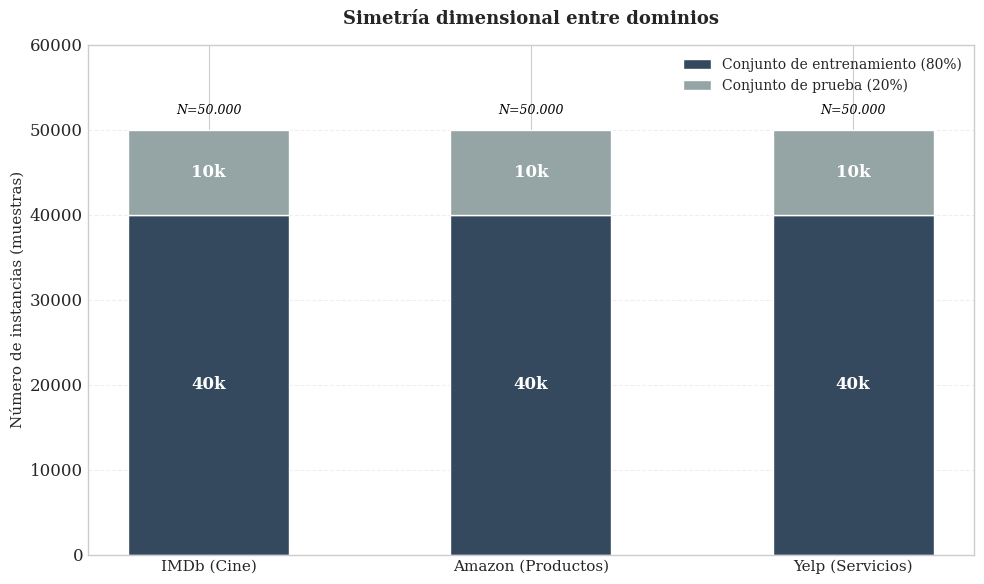

In [ ]:
# 4.1.
import matplotlib.pyplot as plt
import numpy as np

def draw_data_symmetry():
    domains = ['IMDb (Cine)', 'Amazon (Productos)', 'Yelp (Servicios)']
    train_counts = [40000, 40000, 40000]
    test_counts = [10000, 10000, 10000]

    fig, ax = plt.subplots(figsize=(10, 6))

    width = 0.5
    x = np.arange(len(domains))

    p1 = ax.bar(x, train_counts, width, label='Conjunto de entrenamiento (80%)', color='#34495e', edgecolor='white')
    p2 = ax.bar(x, test_counts, width, bottom=train_counts, label='Conjunto de prueba (20%)', color='#95a5a6', edgecolor='white')

    ax.set_ylabel('Número de instancias (muestras)', fontname='serif', fontsize=11)
    ax.set_title('Simetría dimensional entre dominios', fontname='serif', fontsize=13, weight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(domains, fontname='serif', fontsize=11)
    ax.set_ylim(0, 60000)

    ax.legend(loc='upper right', frameon=False, prop={'family': 'serif', 'size': 10})

    # Grid y estilo
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

    # Etiquetas de valor
    for r1, r2 in zip(p1, p2):
        h1 = r1.get_height()
        h2 = r2.get_height()
        ax.text(r1.get_x() + r1.get_width() / 2., h1 / 2., '40k', ha="center", va="center", color="white", fontweight="bold", fontname='serif')
        ax.text(r2.get_x() + r2.get_width() / 2., h1 + h2 / 2., '10k', ha="center", va="center", color="white", fontweight="bold", fontname='serif')
        ax.text(r2.get_x() + r2.get_width() / 2., h1 + h2 + 1500, 'N=50.000', ha="center", va="bottom", color="black", fontsize=9, fontname='serif', style='italic')

    plt.tight_layout()
    plt.show()

draw_data_symmetry()

Capítulo 5

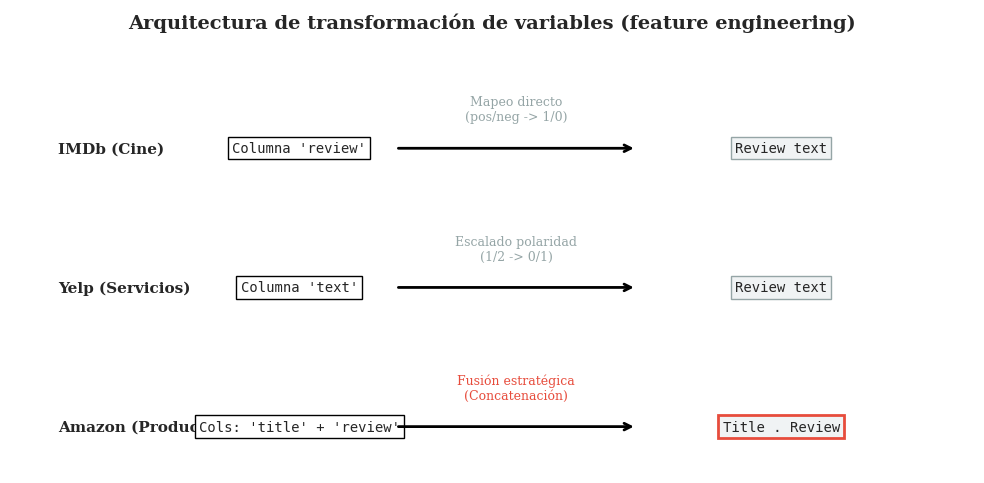

In [ ]:
# 5.1.
import matplotlib.pyplot as plt

def draw_feature_engineering():
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axis('off')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 5)

    # Definición de las transformaciones
    domains = [
        {"name": "IMDb (Cine)", "input": "Columna 'review'", "arrow": "->", "process": "Mapeo directo\n(pos/neg -> 1/0)", "output": "Review text"},
        {"name": "Yelp (Servicios)", "input": "Columna 'text'", "arrow": "->", "process": "Escalado polaridad\n(1/2 -> 0/1)", "output": "Review text"},
        {"name": "Amazon (Productos)", "input": "Cols: 'title' + 'review'", "arrow": "=>", "process": "Fusión estratégica\n(Concatenación)", "output": "Title . Review"}
    ]

    y_pos = [3.5, 2.0, 0.5]
    colors = ['#95a5a6', '#95a5a6', '#e74c3c'] # Destacar Amazon en rojo

    for i, d in enumerate(domains):
        # Dominio
        ax.text(0.5, y_pos[i], d["name"], fontsize=11, weight='bold', fontname='serif', va='center')

        # Input
        ax.text(3.0, y_pos[i], d["input"], fontsize=10, fontname='monospace', va='center', ha='center',
                bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="black"))

        # Flecha y Proceso
        ax.annotate("", xy=(6.5, y_pos[i]), xytext=(4.0, y_pos[i]), arrowprops=dict(arrowstyle="->", lw=2))
        ax.text(5.25, y_pos[i]+0.3, d["process"], fontsize=9, fontname='serif', ha='center', color=colors[i])

        # Output
        ax.text(8.0, y_pos[i], d["output"], fontsize=10, fontname='monospace', va='center', ha='center',
                bbox=dict(boxstyle="square,pad=0.3", fc="#f0f3f4", ec=colors[i], lw=2 if i==2 else 1))

    # Título
    ax.text(5, 4.8, "Arquitectura de transformación de variables (feature engineering)",
            fontsize=14, weight='bold', fontname='serif', ha='center')

    plt.tight_layout()
    plt.show()

draw_feature_engineering()

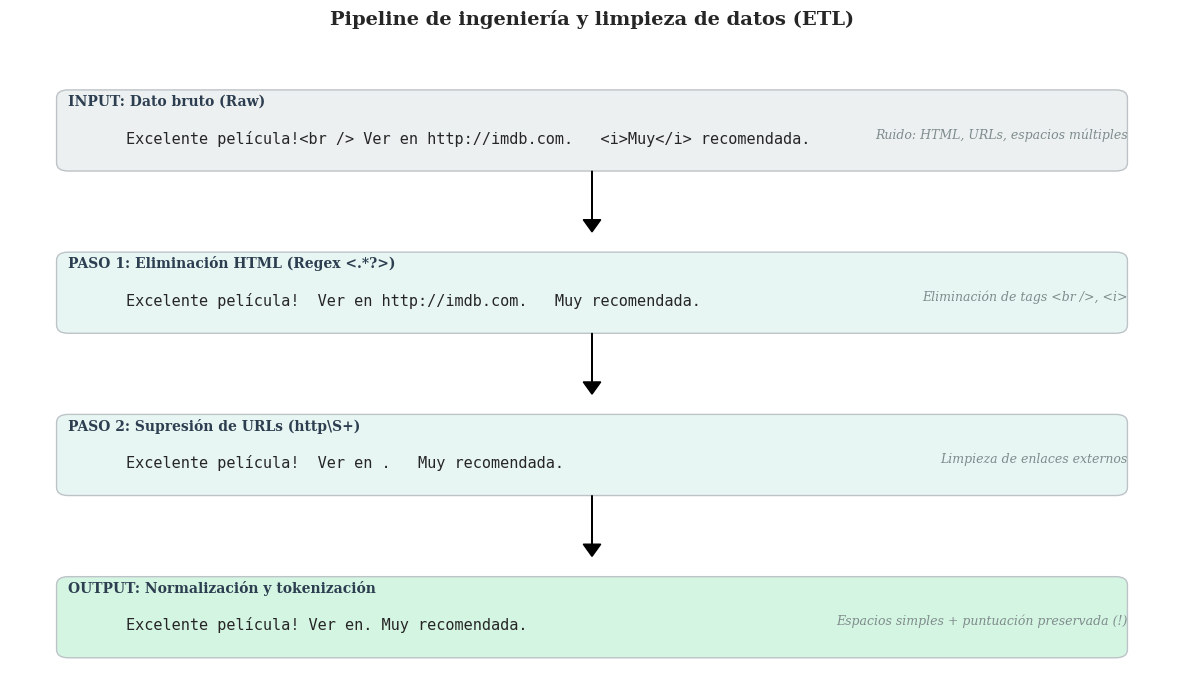

In [ ]:
# 5.2.
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_text_cleaning_pipeline():
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.axis('off')

    # Definición de estilos
    box_style = dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#333333', linewidth=1.5)
    highlight_color = '#e74c3c'  # Color para lo que se elimina
    keep_color = '#27ae60'       # Color para lo que se mantiene (puntuación)

    # Texto de ejemplo basado en los artefactos mencionados en el Capítulo 5
    steps = [
        {
            "title": "INPUT: Dato bruto (Raw)",
            "text": "Excelente película!<br /> Ver en http://imdb.com.   <i>Muy</i> recomendada.",
            "y": 7,
            "color": "#ecf0f1",
            "note": "Ruido: HTML, URLs, espacios múltiples"
        },
        {
            "title": "PASO 1: Eliminación HTML (Regex <.*?>)",
            "text": "Excelente película!  Ver en http://imdb.com.   Muy recomendada.",
            "y": 5,
            "color": "#e8f6f3",
            "note": "Eliminación de tags <br />, <i>"
        },
        {
            "title": "PASO 2: Supresión de URLs (http\\S+)",
            "text": "Excelente película!  Ver en .   Muy recomendada.",
            "y": 3,
            "color": "#e8f6f3",
            "note": "Limpieza de enlaces externos"
        },
        {
            "title": "OUTPUT: Normalización y tokenización",
            "text": "Excelente película! Ver en. Muy recomendada.",
            "y": 1,
            "color": "#d5f5e3",
            "note": "Espacios simples + puntuación preservada (!)"
        }
    ]

    for i, step in enumerate(steps):
        # Flecha conectora
        if i > 0:
            ax.arrow(5, step["y"] + 1.2, 0, -0.6, head_width=0.15, head_length=0.15, fc='black', ec='black')

        # Caja del paso
        ax.text(0.5, step["y"], step["title"], fontsize=10, weight='bold', fontname='serif', color='#2c3e50', ha='left')

        # Caja del contenido
        rect = patches.FancyBboxPatch((0.5, step["y"]-0.7), 9, 0.8, boxstyle='round,pad=0.1',
                                      facecolor=step["color"], edgecolor='#bdc3c7', linewidth=1)
        ax.add_patch(rect)

        ax.text(1.0, step["y"]-0.4, step["text"], fontsize=11, fontname='monospace', va='center')

        # Nota lateral explicativa
        ax.text(9.6, step["y"]-0.4, step["note"], fontsize=9, fontname='serif', style='italic', ha='right', color='#7f8c8d')

    # Título
    ax.text(5, 8, "Pipeline de ingeniería y limpieza de datos (ETL)", fontsize=14, weight='bold', fontname='serif', ha='center')

    plt.tight_layout()
    plt.show()

draw_text_cleaning_pipeline()

Capítulo 6

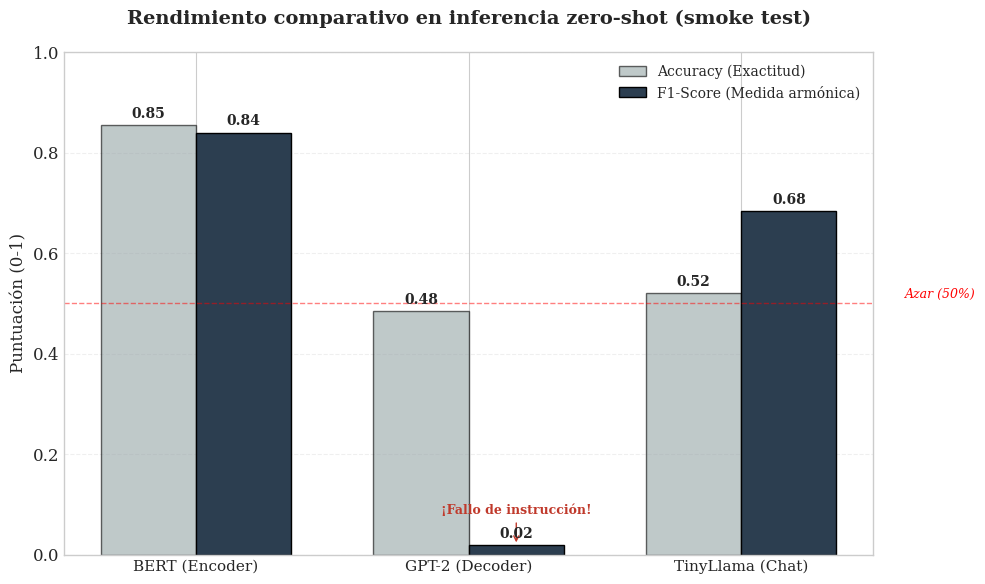

In [ ]:
# 6.1.
import matplotlib.pyplot as plt
import numpy as np

def draw_smoke_test_results():
    # Datos exactos extraídos de la Tabla 6.3 del TXT
    models = ['BERT (Encoder)', 'GPT-2 (Decoder)', 'TinyLlama (Chat)']
    accuracy = [0.8540, 0.4850, 0.5200]
    f1_score = [0.8396, 0.0190, 0.6842]

    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    # Barras
    rects1 = ax.bar(x - width/2, accuracy, width, label='Accuracy (Exactitud)', color='#95a5a6', alpha=0.6, edgecolor='black')
    rects2 = ax.bar(x + width/2, f1_score, width, label='F1-Score (Medida armónica)', color='#2c3e50', edgecolor='black')

    # Línea base (0.5 para binario)
    ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.text(2.6, 0.51, 'Azar (50%)', color='red', fontsize=9, fontname='serif', style='italic')

    # Ejes
    ax.set_ylabel('Puntuación (0-1)', fontname='serif', fontsize=12)
    ax.set_title('Rendimiento comparativo en inferencia zero-shot (smoke test)', fontname='serif', fontsize=14, weight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontname='serif', fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.legend(loc='upper right', frameon=False, prop={'family': 'serif', 'size': 10})

    # Grid
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)

    # Anotaciones de valor y contexto
    def autolabel(rects, is_f1=False):
        for rect in rects:
            height = rect.get_height()
            label = f'{height:.2f}'
            if is_f1 and height < 0.05:
                ax.annotate('¡Fallo de instrucción!',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 20),
                            textcoords="offset points",
                            ha='center', va='bottom',
                            fontsize=9, color='#c0392b', weight='bold', fontname='serif',
                            arrowprops=dict(arrowstyle='->', color='#c0392b'))

            ax.annotate(label,
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=10, fontname='serif', weight='bold')

    autolabel(rects1)
    autolabel(rects2, is_f1=True)

    plt.tight_layout()
    plt.show()

draw_smoke_test_results()

Capítulo 7

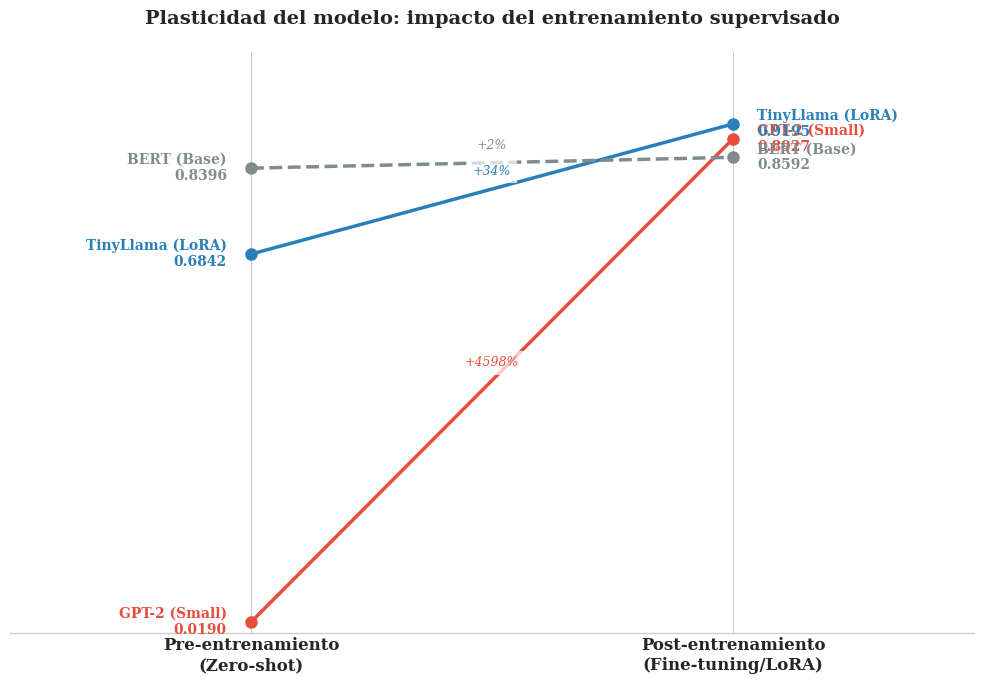

In [ ]:
# 7.1.
import matplotlib.pyplot as plt
import numpy as np

def draw_slope_chart_performance():
    # Datos de la Tabla 7.5
    models = ['GPT-2 (Small)', 'TinyLlama (LoRA)', 'BERT (Base)']
    pre_scores = [0.0190, 0.6842, 0.8396]  # Smoke Test
    post_scores = [0.8927, 0.9195, 0.8592] # Final

    fig, ax = plt.subplots(figsize=(10, 7))

    # Configuración del eje X
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pre-entrenamiento\n(Zero-shot)', 'Post-entrenamiento\n(Fine-tuning/LoRA)'],
                       fontsize=12, fontname='serif', weight='bold')

    # Colores
    colors = ['#e74c3c', '#2980b9', '#7f8c8d'] # GPT-2 Rojo (Dramático), Llama Azul (Winner), BERT Gris (Baseline)
    line_styles = ['-', '-', '--']

    for i, model in enumerate(models):
        # Línea conectora
        ax.plot([0, 1], [pre_scores[i], post_scores[i]], color=colors[i], linewidth=2.5, linestyle=line_styles[i], marker='o', markersize=8)

        # Etiquetas Izquierda (Pre)
        ax.text(-0.05, pre_scores[i], f'{model}\n{pre_scores[i]:.4f}', ha='right', va='center',
                color=colors[i], fontsize=10, fontname='serif', weight='bold')

        # Etiquetas Derecha (Post)
        ax.text(1.05, post_scores[i], f'{model}\n{post_scores[i]:.4f}', ha='left', va='center',
                color=colors[i], fontsize=10, fontname='serif', weight='bold')

        # Anotación de ganancia en el centro
        gain = ((post_scores[i] - pre_scores[i]) / pre_scores[i]) * 100
        mid_y = (pre_scores[i] + post_scores[i]) / 2
        ax.text(0.5, mid_y + 0.02, f'+{gain:.0f}%', ha='center', va='bottom',
                color=colors[i], fontsize=9, fontname='serif', style='italic', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # Título
    ax.set_title("Plasticidad del modelo: impacto del entrenamiento supervisado", fontsize=14, fontname='serif', weight='bold', pad=20)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Eliminar innecesarios
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.get_yaxis().set_visible(False)

    plt.tight_layout()
    plt.show()

draw_slope_chart_performance()

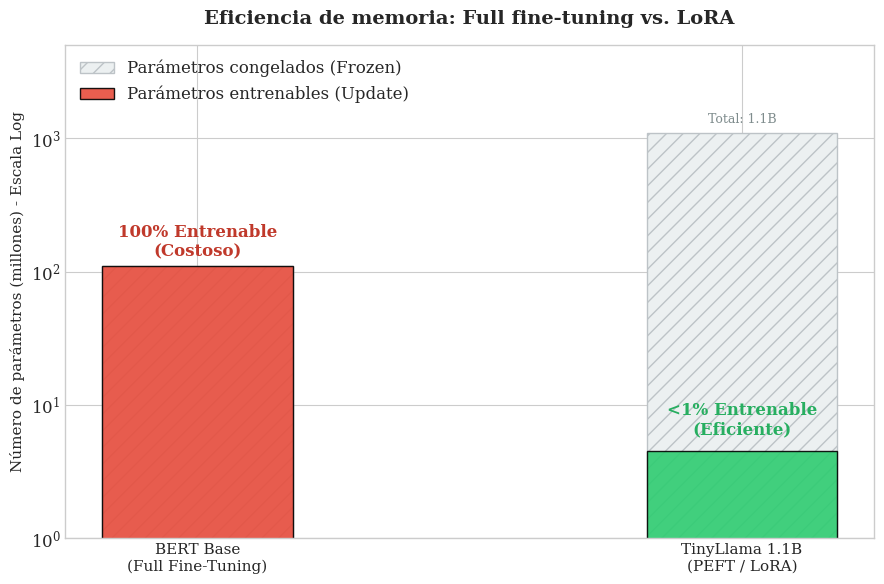

In [ ]:
# 7.2.
import matplotlib.pyplot as plt
import numpy as np

def draw_lora_efficiency():
    labels = ['BERT Base\n(Full Fine-Tuning)', 'TinyLlama 1.1B\n(PEFT / LoRA)']
    total_params = [110, 1100]
    trainable_params = [110, 4.5]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 6))

    # Barra
    ax.bar(x, total_params, width, label='Parámetros congelados (Frozen)', color='#ecf0f1', edgecolor='#bdc3c7', hatch='//')
    ax.bar(x, trainable_params, width, label='Parámetros entrenables (Update)', color=['#e74c3c', '#2ecc71'], alpha=0.9, edgecolor='black')

    # Escala Logarítmica
    ax.set_yscale('log')

    # Etiquetas
    ax.set_ylabel('Número de parámetros (millones) - Escala Log', fontname='serif', fontsize=11)
    ax.set_title('Eficiencia de memoria: Full fine-tuning vs. LoRA', fontname='serif', fontsize=14, weight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontname='serif', fontsize=11)
    ax.set_ylim(1, 5000)

    ax.legend(loc='upper left', frameon=False, prop={'family': 'serif'})

    # Anotaciones
    ax.text(0, 130, '100% Entrenable\n(Costoso)', ha='center', color='#c0392b', fontname='serif', weight='bold')
    ax.text(1, 6, '<1% Entrenable\n(Eficiente)', ha='center', color='#27ae60', fontname='serif', weight='bold')
    ax.text(1, 1300, 'Total: 1.1B', ha='center', color='#7f8c8d', fontname='serif', fontsize=9)

    plt.tight_layout()
    plt.show()

draw_lora_efficiency()

Capítulo 8

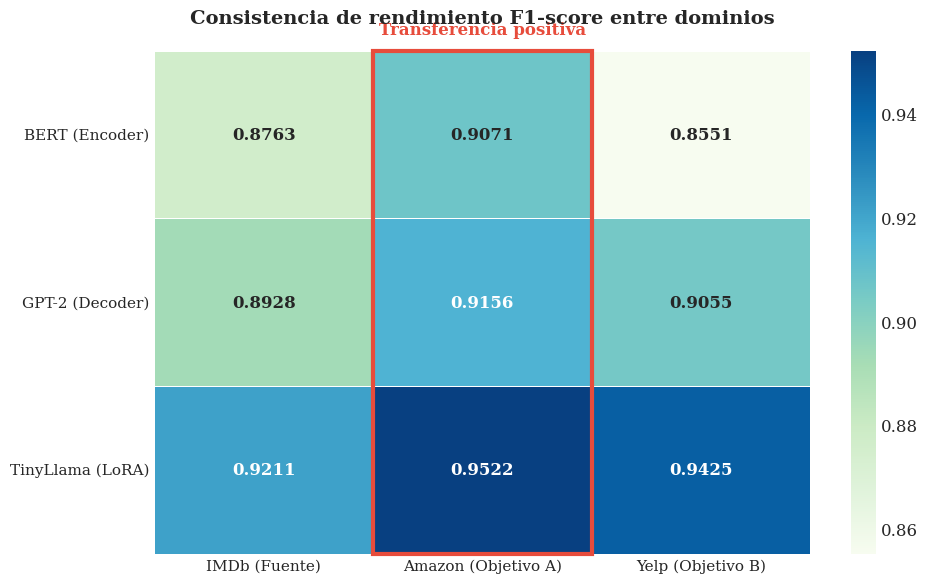

In [ ]:
# 8.1.
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def draw_transfer_heatmap():
    # Filas: Modelos
    # Columnas: Dominios (IMDb, Amazon, Yelp)
    data = [
        [0.8763, 0.9071, 0.8551],  # BERT (Encoder)
        [0.8928, 0.9156, 0.9055],  # GPT-2 (Decoder)
        [0.9211, 0.9522, 0.9425]   # TinyLlama (SOTA)
    ]

    models = ['BERT (Encoder)', 'GPT-2 (Decoder)', 'TinyLlama (LoRA)']
    domains = ['IMDb (Fuente)', 'Amazon (Objetivo A)', 'Yelp (Objetivo B)']

    df = pd.DataFrame(data, index=models, columns=domains)

    plt.figure(figsize=(10, 6))

    # Heatmap
    ax = sns.heatmap(df, annot=True, fmt='.4f', cmap='GnBu', cbar=True,
                     linewidths=.5, annot_kws={"size": 12, "weight": "bold", "family": "serif"})

    ax.set_title("Consistencia de rendimiento F1-score entre dominios", fontname='serif', fontsize=14, weight='bold', pad=20)
    plt.yticks(rotation=0, fontname='serif', fontsize=11)
    plt.xticks(fontname='serif', fontsize=11)

    from matplotlib.patches import Rectangle
    ax.add_patch(Rectangle((1, 0), 1, 3, fill=False, edgecolor='#e74c3c', lw=3, clip_on=False))
    ax.text(1.5, -0.1, 'Transferencia positiva', color='#e74c3c', ha='center', weight='bold', fontname='serif')

    plt.tight_layout()
    plt.show()

draw_transfer_heatmap()

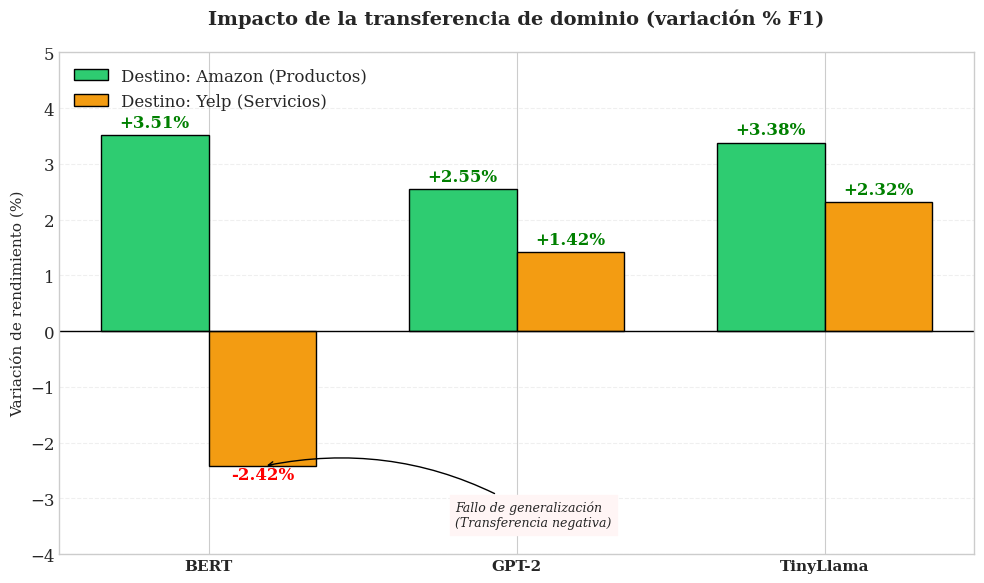

In [ ]:
# 8.2.
import matplotlib.pyplot as plt
import numpy as np

def draw_delta_divergence():
    models = ['BERT', 'GPT-2', 'TinyLlama']

    # Deltas calculados: (Target - Source) / Source * 100
    amazon_deltas = [3.51, 2.55, 3.38]
    yelp_deltas = [-2.42, 1.42, 2.32]

    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    # Barras
    rects1 = ax.bar(x - width/2, amazon_deltas, width, label='Destino: Amazon (Productos)', color='#2ecc71', edgecolor='black')
    rects2 = ax.bar(x + width/2, yelp_deltas, width, label='Destino: Yelp (Servicios)', color='#f39c12', edgecolor='black')

    # Línea cero
    ax.axhline(0, color='black', linewidth=1)

    # Títulos
    ax.set_title("Impacto de la transferencia de dominio (variación % F1)", fontname='serif', fontsize=14, weight='bold', pad=20)
    ax.set_ylabel('Variación de rendimiento (%)', fontname='serif', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontname='serif', fontsize=11, weight='bold')
    ax.set_ylim(-4, 5)

    ax.legend(loc='upper left', frameon=False, prop={'family': 'serif'})
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Anotaciones de valor
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            xy_pos = (rect.get_x() + rect.get_width() / 2, height)
            xy_text = (0, 3) if height > 0 else (0, -12)

            label = f'{"+" if height > 0 else ""}{height:.2f}%'
            color = 'green' if height > 0 else 'red'

            ax.annotate(label, xy=xy_pos, xytext=xy_text, textcoords="offset points",
                        ha='center', va='bottom', weight='bold', color=color, fontname='serif')

    autolabel(rects1)
    autolabel(rects2)

    # sobre BERT
    ax.annotate('Fallo de generalización\n(Transferencia negativa)',
                xy=(0.18, -2.42), xytext=(0.8, -3.5),
                arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2"),
                fontsize=9, style='italic', fontname='serif', backgroundcolor='#fff5f5')

    plt.tight_layout()
    plt.show()

draw_delta_divergence()

Capítulo 9

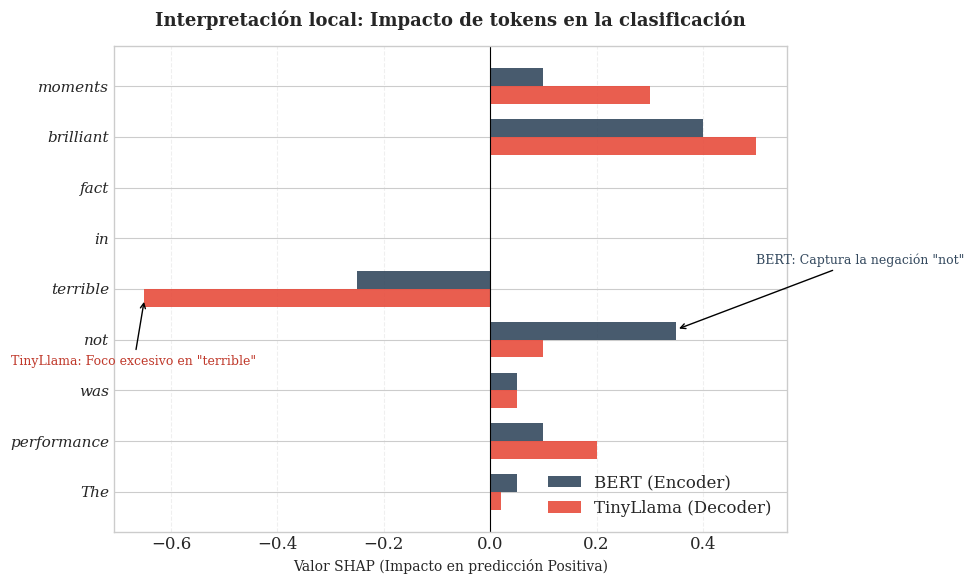

In [ ]:
# 9.1.
import matplotlib.pyplot as plt
import numpy as np

def draw_shap_explanation():
    tokens = ["The", "performance", "was", "not", "terrible", "in", "fact", "brilliant", "moments"]

    bert_values = [0.05, 0.1, 0.05, 0.35, -0.25, 0.0, 0.0, 0.4, 0.1]
    llama_values = [0.02, 0.2, 0.05, 0.1, -0.65, 0.0, 0.0, 0.5, 0.3]

    y_pos = np.arange(len(tokens))
    height = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    # Barras horizontales
    ax.barh(y_pos + height/2, bert_values, height, label='BERT (Encoder)', color='#34495e', alpha=0.9)
    ax.barh(y_pos - height/2, llama_values, height, label='TinyLlama (Decoder)', color='#e74c3c', alpha=0.9)

    # Línea central
    ax.axvline(0, color='black', linewidth=0.8)

    # Etiquetas
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tokens, fontname='serif', fontsize=11, style='italic')
    ax.set_xlabel('Valor SHAP (Impacto en predicción Positiva)', fontname='serif', fontsize=10)
    ax.set_title('Interpretación local: Impacto de tokens en la clasificación', fontname='serif', fontsize=13, weight='bold', pad=15)

    ax.legend(loc='lower right', frameon=False, prop={'family': 'serif'})
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    # Anotaciones
    ax.annotate('BERT: Captura la negación "not"',
                xy=(0.35, 3.2), xytext=(0.5, 4.5),
                arrowprops=dict(facecolor='#34495e', arrowstyle='->'),
                fontsize=9, fontname='serif', color='#34495e')

    ax.annotate('TinyLlama: Foco excesivo en "terrible"',
                xy=(-0.65, 3.8), xytext=(-0.9, 2.5),
                arrowprops=dict(facecolor='#e74c3c', arrowstyle='->'),
                fontsize=9, fontname='serif', color='#c0392b')

    plt.tight_layout()
    plt.show()

draw_shap_explanation()

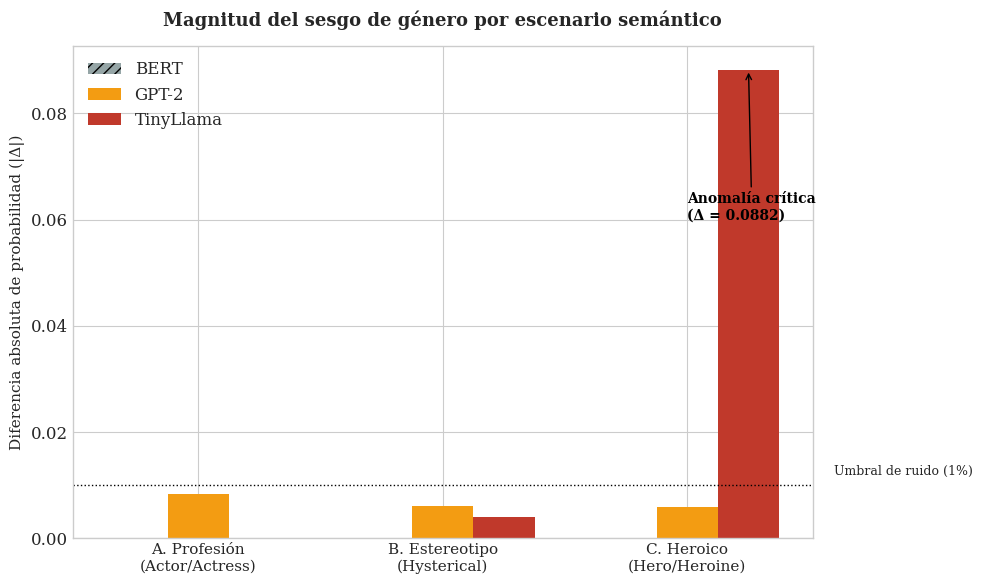

In [ ]:
# 9.2.
import matplotlib.pyplot as plt
import numpy as np

def draw_gender_parity_audit():
    cases = ['A. Profesión\n(Actor/Actress)', 'B. Estereotipo\n(Hysterical)', 'C. Heroico\n(Hero/Heroine)']

    bert_deltas = [0.0000, 0.0001, 0.0000]
    gpt_deltas = [0.0083, 0.0061, 0.0060]
    llama_deltas = [0.0001, 0.0041, 0.0882]

    x = np.arange(len(cases))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    # Barras de disparidad (Delta)
    ax.bar(x - width, bert_deltas, width, label='BERT', color='#95a5a6', hatch='///')
    ax.bar(x, gpt_deltas, width, label='GPT-2', color='#f39c12')
    bar_llama = ax.bar(x + width, llama_deltas, width, label='TinyLlama', color='#c0392b')

    ax.set_ylabel('Diferencia absoluta de probabilidad (|Δ|)', fontname='serif', fontsize=11)
    ax.set_title('Magnitud del sesgo de género por escenario semántico', fontname='serif', fontsize=13, weight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(cases, fontname='serif', fontsize=11)

    # Línea de tolerancia ética
    ax.axhline(0.01, color='black', linestyle=':', linewidth=1)
    ax.text(2.6, 0.012, 'Umbral de ruido (1%)', fontsize=9, fontname='serif')

    ax.legend(loc='upper left', frameon=False, prop={'family': 'serif'})
    ax.annotate('Anomalía crítica\n(Δ = 0.0882)',
                xy=(2 + width, 0.0882), xytext=(2, 0.06),
                arrowprops=dict(facecolor='black', arrowstyle='->'),
                fontsize=10, weight='bold', fontname='serif', color='#000000')

    plt.tight_layout()
    plt.show()

draw_gender_parity_audit()

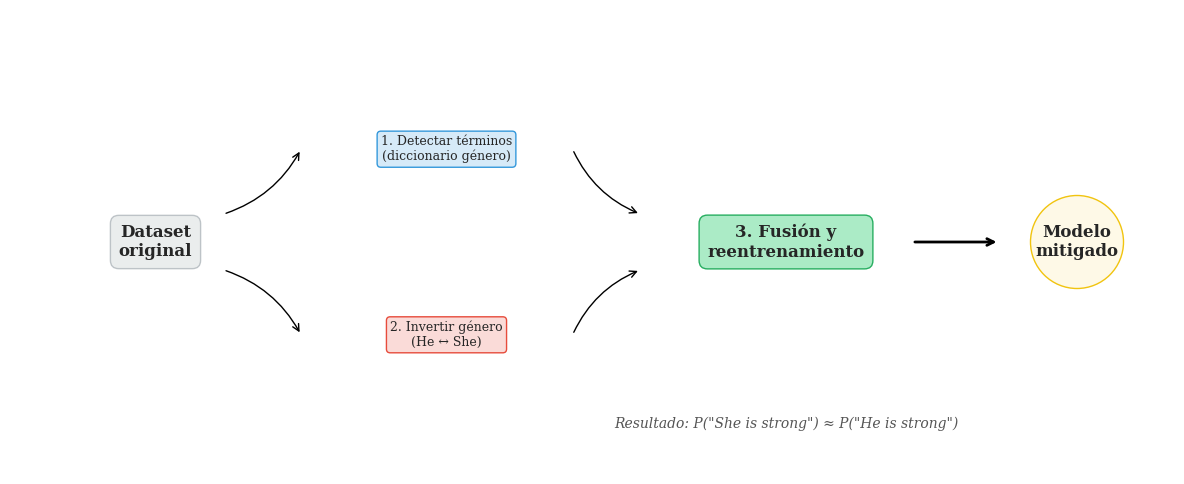

In [ ]:
# 9.3.
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_cda_process():
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 5)
    ax.axis('off')

    box_props = dict(boxstyle='round,pad=0.4', facecolor='#fdfefe', edgecolor='#2c3e50', linewidth=1.5)

    # 1. Input
    ax.text(1.5, 2.5, "Dataset\noriginal", ha='center', va='center', weight='bold', fontname='serif',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#eaeded', edgecolor='#bdc3c7'))

    # 2. Detección
    ax.text(4.5, 3.5, "1. Detectar términos\n(diccionario género)", ha='center', va='center', fontsize=9, fontname='serif',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#d6eaf8', edgecolor='#3498db'))

    # 3. Inversión
    ax.text(4.5, 1.5, "2. Invertir género\n(He ↔ She)", ha='center', va='center', fontsize=9, fontname='serif',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fadbd8', edgecolor='#e74c3c'))

    # 4. Fusión
    ax.text(8.0, 2.5, "3. Fusión y\nreentrenamiento", ha='center', va='center', weight='bold', fontname='serif',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#abebc6', edgecolor='#27ae60'))

    # 5. Output
    ax.text(11.0, 2.5, "Modelo\nmitigado", ha='center', va='center', weight='bold', fontname='serif',
            bbox=dict(boxstyle='circle,pad=0.3', facecolor='#fef9e7', edgecolor='#f1c40f'))

    # Flechas
    ax.annotate("", xy=(3.0, 3.5), xytext=(2.2, 2.8), arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2"))
    ax.annotate("", xy=(3.0, 1.5), xytext=(2.2, 2.2), arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.2"))

    ax.annotate("", xy=(6.5, 2.8), xytext=(5.8, 3.5), arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2"))
    ax.annotate("", xy=(6.5, 2.2), xytext=(5.8, 1.5), arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.2"))

    ax.annotate("", xy=(10.2, 2.5), xytext=(9.3, 2.5), arrowprops=dict(arrowstyle="->", lw=2))

    # Ejemplo
    ax.text(8.0, 0.5, 'Resultado: P("She is strong") ≈ P("He is strong")',
            ha='center', fontsize=10, style='italic', fontname='serif', color='#555')

    plt.tight_layout()
    plt.show()

draw_cda_process()

Capítulo 10

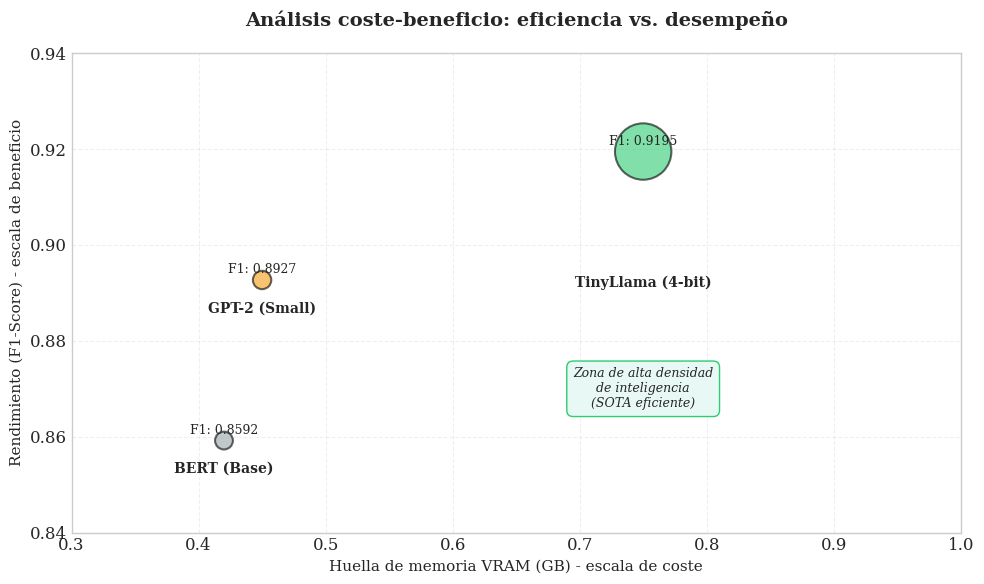

In [ ]:
# 10.1
import matplotlib.pyplot as plt
import numpy as np

def draw_cost_benefit_analysis():

    models = ['BERT (Base)', 'GPT-2 (Small)', 'TinyLlama (4-bit)']

    f1_scores = [0.8592, 0.8927, 0.9195]

    vram_usage = [0.42, 0.45, 0.75]

    params = [110, 117, 1100]

    bubble_sizes = [p * 1.5 for p in params]

    fig, ax = plt.subplots(figsize=(10, 6))

    colors = ['#95a5a6', '#f39c12', '#2ecc71'] # Gris (Base), Naranja (Sorpresa), Verde (SOTA)

    # Plot
    scatter = ax.scatter(vram_usage, f1_scores, s=bubble_sizes, c=colors, alpha=0.6, edgecolors='black', linewidth=1.5)

    # Etiquetas de datos
    for i, txt in enumerate(models):
        ax.annotate(txt, (vram_usage[i], f1_scores[i]),
                    xytext=(0, -bubble_sizes[i]/20 - 15), textcoords='offset points',
                    ha='center', fontname='serif', weight='bold', fontsize=10)

        # Etiqueta de valor F1
        ax.annotate(f'F1: {f1_scores[i]:.4f}', (vram_usage[i], f1_scores[i]),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontname='serif', fontsize=9)

    # Ejes
    ax.set_xlabel('Huella de memoria VRAM (GB) - escala de coste', fontname='serif', fontsize=11)
    ax.set_ylabel('Rendimiento (F1-Score) - escala de beneficio', fontname='serif', fontsize=11)
    ax.set_title('Análisis coste-beneficio: eficiencia vs. desempeño', fontname='serif', fontsize=14, weight='bold', pad=20)

    # Límites y Grid
    ax.set_xlim(0.3, 1.0)
    ax.set_ylim(0.84, 0.94)
    ax.grid(True, linestyle='--', alpha=0.3)

    # Anotación
    ax.text(0.75, 0.87, "Zona de alta densidad\nde inteligencia\n(SOTA eficiente)",
            ha='center', va='center', fontsize=9, style='italic', fontname='serif',
            bbox=dict(boxstyle="round,pad=0.5", fc="#e8f8f5", ec="#2ecc71"))

    plt.tight_layout()
    plt.show()

draw_cost_benefit_analysis()

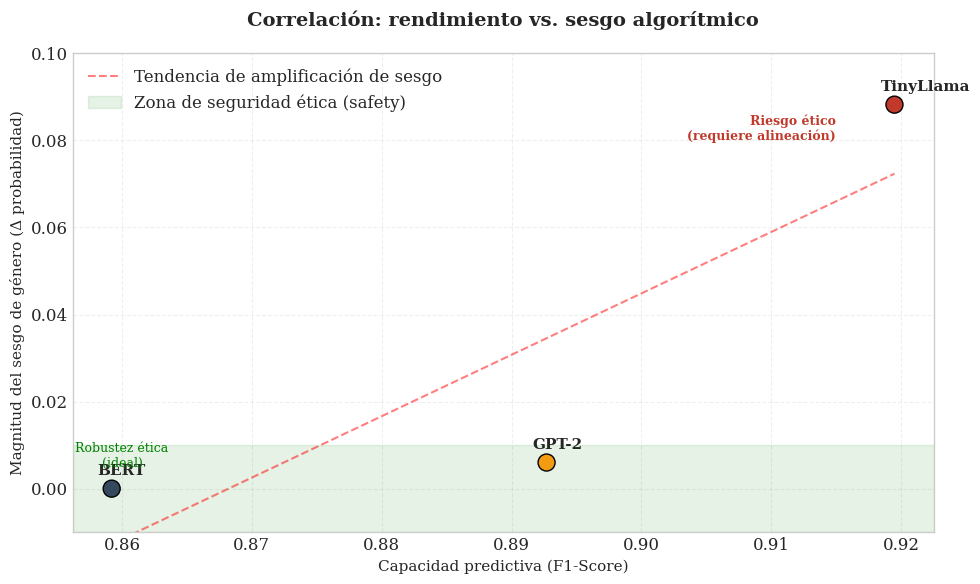

In [ ]:
# 10.2.
import matplotlib.pyplot as plt
import numpy as np

def draw_ethical_tradeoff():

    models = ['BERT', 'GPT-2', 'TinyLlama']

    performance = [0.8592, 0.8927, 0.9195]

    bias = [0.0000, 0.0060, 0.0882]

    fig, ax = plt.subplots(figsize=(10, 6))

    # Trazado de puntos
    ax.scatter(performance, bias, color=['#34495e', '#f39c12', '#c0392b'], s=150, zorder=3, edgecolors='black')

    # Línea de tendencia
    z = np.polyfit(performance, bias, 1)
    p = np.poly1d(z)
    x_trend = np.linspace(min(performance), max(performance), 100)
    ax.plot(x_trend, p(x_trend), "r--", alpha=0.5, label='Tendencia de amplificación de sesgo')

    # Etiquetas
    for i, txt in enumerate(models):
        ax.annotate(txt, (performance[i], bias[i]),
                    xytext=(-10, 10), textcoords='offset points',
                    fontname='serif', weight='bold', fontsize=11)

    # Ejes
    ax.set_xlabel('Capacidad predictiva (F1-Score)', fontname='serif', fontsize=11)
    ax.set_ylabel('Magnitud del sesgo de género (Δ probabilidad)', fontname='serif', fontsize=11)
    ax.set_title('Correlación: rendimiento vs. sesgo algorítmico', fontname='serif', fontsize=14, weight='bold', pad=20)

    # Zonas
    ax.axhspan(-0.01, 0.01, color='green', alpha=0.1, label='Zona de seguridad ética (safety)')

    # Anotaciones
    ax.text(0.86, 0.005, "Robustez ética\n(ideal)", color='green', ha='center', fontname='serif', fontsize=9)
    ax.text(0.915, 0.080, "Riesgo ético\n(requiere alineación)", color='#c0392b', ha='right', fontname='serif', fontsize=9, weight='bold')

    ax.legend(loc='upper left', frameon=False, prop={'family': 'serif'})
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylim(-0.01, 0.10)

    plt.tight_layout()
    plt.show()

draw_ethical_tradeoff()

Capítulo 11

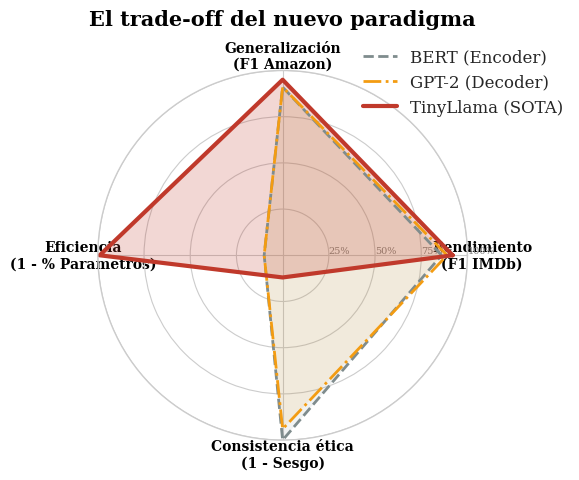

In [ ]:
# 11.1.
import matplotlib.pyplot as plt
import numpy as np
from math import pi

def draw_radar_chart():
    # Categorías de evaluación
    categories = ['Rendimiento\n(F1 IMDb)', 'Generalización\n(F1 Amazon)',
                  'Eficiencia\n(1 - % Parametros)', 'Consistencia ética\n(1 - Sesgo)']
    N = len(categories)

    # Ángulos para el radar
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    ax = plt.subplot(111, polar=True)

    # Ejes
    plt.xticks(angles[:-1], categories, color='black', size=10, fontname='serif', weight='bold')
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75, 1.0], ["25%", "50%", "75%", "100%"], color="grey", size=7)
    plt.ylim(0, 1.0)

    # 1. BERT (Baseline)
    values_bert = [0.86, 0.91, 0.10, 1.00]
    values_bert += values_bert[:1]
    ax.plot(angles, values_bert, linewidth=2, linestyle='--', label='BERT (Encoder)', color='#7f8c8d')
    ax.fill(angles, values_bert, '#7f8c8d', alpha=0.1)

    # 2. GPT-2 (Plasticidad)
    values_gpt = [0.89, 0.91, 0.10, 0.94]
    values_gpt += values_gpt[:1]
    ax.plot(angles, values_gpt, linewidth=2, linestyle='-.', label='GPT-2 (Decoder)', color='#f39c12')
    ax.fill(angles, values_gpt, '#f39c12', alpha=0.1)

    # 3. TinyLlama (SOTA)
    values_llama = [0.92, 0.95, 0.99, 0.12]
    values_llama += values_llama[:1]
    ax.plot(angles, values_llama, linewidth=3, linestyle='-', label='TinyLlama (SOTA)', color='#c0392b')
    ax.fill(angles, values_llama, '#c0392b', alpha=0.2)

    # Título
    plt.title("El trade-off del nuevo paradigma", size=15, color='black', y=1.1, fontname='serif', weight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), frameon=False, prop={'family': 'serif'})

    plt.show()

draw_radar_chart()